<a href="https://colab.research.google.com/github/AbdallaYoussef006/FlyRank-AI/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research question

Can current-month search performance signals identify content that is likely to experience an impressions decline in the following month?

The decision supported is content prioritization: identifying pages that may deserve review before a decline becomes larger.

This analysis is predictive and decision-support oriented. It does not claim that any individual search signal causes a future decline or that it proves how Google's ranking system works.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data

This analysis uses the full FlyRank warehouse release and the fact_daily table.

The available release contains 78,835,655 rows covering 70 clients and 427,292 content records from 2025-01-27 through 2026-06-30.

For modeling, the data was aggregated to a monthly content-level dataset. The resulting modeling table contains 1,329,512 rows, 66 clients, and 288,308 content records.

The analysis uses anonymized client and content identifiers and does not expose client names, domains, URLs, private queries, credentials, or raw exports.

The model uses current-month impressions, clicks, CTR, average position, scroll events, and AI-session activity. The next month's impressions are used only to construct the outcome label.

Rows without a valid next-month outcome are not used for supervised modeling.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Split design

A grouped train/test split was used by client.

The 66 clients in the modeling dataset were divided into 52 training clients and 14 testing clients. No client appeared in both sets.

The same split was used for the baseline and Random Forest so that the comparison was fair.

The model uses only current-month information as features. The next-month impressions value is used only to construct the target and is excluded from the feature set.

This prevents future outcome information from entering the model features. The leakage check returned PASS.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Results

The Random Forest achieved 60.28% accuracy, 49.42% precision, 61.17% recall, and an F1 score of 54.67% on the held-out client test set.

Compared with the Week-4 rule-based baseline, the Random Forest improved accuracy from 39.16% to 60.28% and precision from 39.16% to 49.42%.

However, the baseline had higher recall (100.00%) and a slightly higher F1 score (56.28%) than the Random Forest.

Therefore, the model should not be described as universally better than the baseline. Instead, it provides a different trade-off: fewer positive predictions are made, but the predictions are more selective and the overall accuracy is higher.

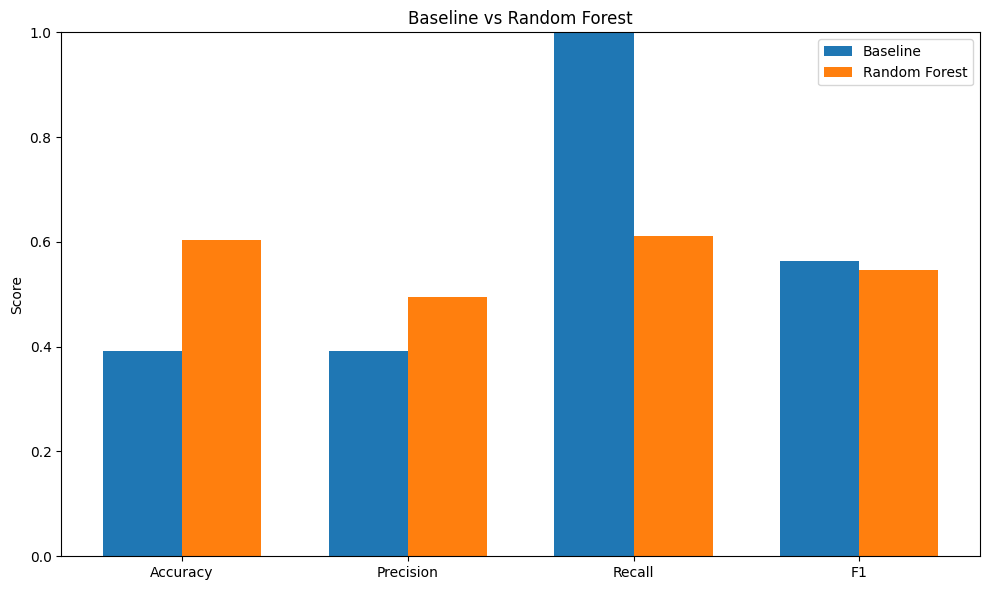

In [19]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1"]

baseline_values = [
    baseline_results["Accuracy"],
    baseline_results["Precision"],
    baseline_results["Recall"],
    baseline_results["F1"]
]

rf_values = [
    rf_results["Accuracy"],
    rf_results["Precision"],
    rf_results["Recall"],
    rf_results["F1"]
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, baseline_values, width, label="Baseline")
plt.bar(x + width/2, rf_values, width, label="Random Forest")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Baseline vs Random Forest")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

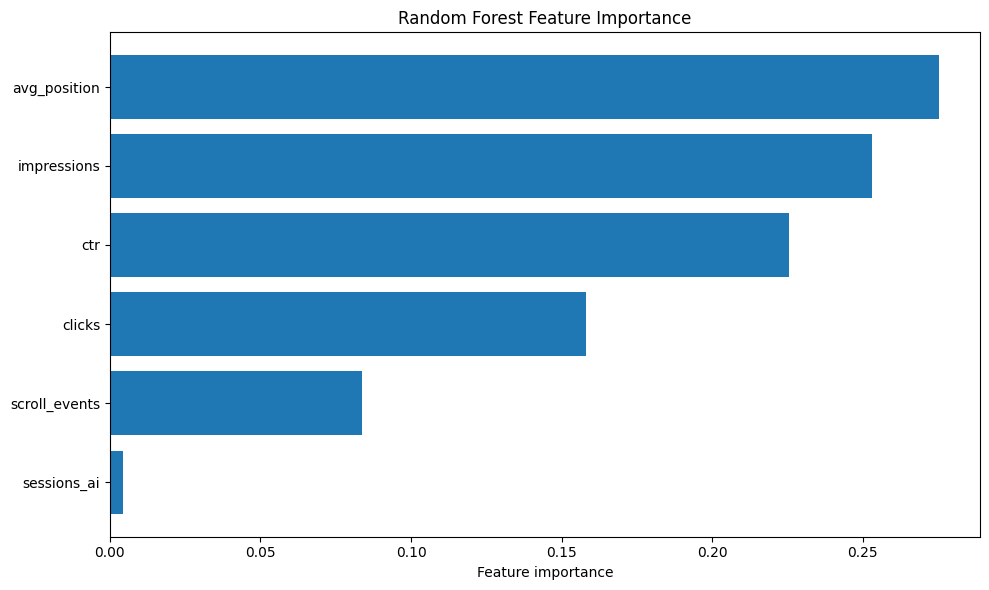

In [20]:
importance_df = pd.DataFrame({
    "feature": [
        "avg_position",
        "impressions",
        "ctr",
        "clicks",
        "scroll_events",
        "sessions_ai"
    ],
    "importance": [
        0.275129,
        0.253018,
        0.225564,
        0.158050,
        0.083747,
        0.004492
    ]
})

importance_df = importance_df.sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Feature importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

## 5. Error analysis

You already have:

False positives: 50,151

False negatives: 31,105

Average impressions:

FP: 1,622.67

FN: 1,493.18

Average position:

FP: 23.67

FN: 17.10

Error analysis

The model produced 50,151 false positives and 31,105 false negatives on the test set.

False positives had an average of approximately 1,623 impressions and an average position of 23.67, while false negatives had approximately 1,493 impressions and an average position of 17.10.

This suggests that some prediction errors occur on content with different levels of search visibility and ranking position. The model should therefore be treated as a prioritization signal rather than a definitive classification of future decline.

The model's feature importance also shows that average position, impressions, CTR, and clicks contribute most strongly to its predictions.

## 6. Limitations



Limitations

This analysis identifies predictive associations in the available FlyRank data. It does not establish causation.

The train/test split is grouped by client rather than time-aware, so the evaluation tests generalization to unseen clients rather than future performance across time.

The target represents an impressions decline between the current month and the following month. Other factors may influence future performance but are not represented in the selected features.

The Random Forest also does not outperform the baseline on every metric. In particular, the baseline has higher recall and a slightly higher F1 score.

Therefore, the model should be used as decision support for prioritizing content review, not as an automated final decision maker.

# 7. Ranked recommendations

This is the part we still need to build.

Your feature importance gives us the basis:

1. Average position — 27.51%

2. Impressions — 25.30%

3. CTR — 22.56%

4. Clicks — 15.81%

5. Scroll events — 8.37%

6. AI sessions — 0.45%

So your action playbook can be:

Ranked recommendations

1. Review content with weaker average positions
Average position is the strongest model feature. Pages showing weaker search positions should receive priority for content review and monitoring.

2. Prioritize pages with meaningful impressions but signs of decline
Impressions are the second strongest feature. Pages with substantial existing visibility may represent higher-value opportunities for review.

3. Investigate CTR underperformance
CTR is one of the strongest predictive signals. Pages with visibility but relatively weak click-through performance should be reviewed for metadata, search intent alignment, and content presentation.

4. Monitor click losses
Clicks provide additional information beyond impressions and CTR. Declining clicks should be considered alongside visibility and position rather than independently.

5. Use engagement signals as supporting evidence
Scroll events contribute to the model but are less important than the main search-performance signals. They should therefore be used as secondary evidence.

6. Treat AI-session activity as a monitoring signal
AI-session activity has very low feature importance in this model. It should not drive prioritization on its own.

#8. Reproducibility

Reproducibility

The analysis was developed using Python, DuckDB, pandas, and scikit-learn.

The workflow queries the FlyRank warehouse without downloading the complete warehouse into memory.

The repository contains the weekly assignment notebooks and the capstone notebook used to produce this analysis.

The final deployed research paper is linked from submission/paper_url.txt in the repository.

# 9. Acknowledgments

Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

This project was completed as part of the FlyRank ML Internship track. The analysis uses the anonymized search-performance warehouse provided for the internship.

Data source: FlyRank.